# Phát Hiện Ngã (Fall Detection) Dựa Trên Dữ Liệu Cảm Biến IMU


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

import tensorflow as tf
from tensorflow.keras import Model, Input, layers
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)
print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.21.0


In [11]:
from pathlib import Path


FALL_RATIO_THRESHOLD = 0.20


def resolve_dataset_path(*relative_candidates):
    """Resolve dataset paths whether the notebook runs from workspace or project root."""
    candidates = [Path.cwd() / candidate for candidate in relative_candidates]
    candidates.extend(Path.cwd().parent / candidate for candidate in relative_candidates)
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    searched = ", ".join(str(candidate) for candidate in candidates)
    raise FileNotFoundError(f"Không tìm thấy dataset. Đã tìm: {searched}")


def load_imu_dataset(data_path):
    """Read every CSV below a dataset directory and add leakage-safe identifiers."""
    data_path = Path(data_path)
    csv_files = sorted(data_path.rglob("*.csv"))
    print(f"Đang đọc {len(csv_files)} file CSV từ: {data_path}")

    required_cols = {
        "AccX", "AccY", "AccZ", "GyrX", "GyrY", "GyrZ",
        "EulerX", "EulerY", "EulerZ", "FallCheck"
    }
    dfs = []
    for file_path in csv_files:
        df = pd.read_csv(file_path)
        missing_cols = required_cols.difference(df.columns)
        if missing_cols:
            raise ValueError(f"{file_path} thiếu cột: {sorted(missing_cols)}")

        relative_path = file_path.relative_to(data_path)
        df["source_file"] = file_path.name
        df["recording_id"] = relative_path.with_suffix("").as_posix()
        df["subject_id"] = file_path.parent.name
        df["AccMag"] = np.sqrt(df["AccX"]**2 + df["AccY"]**2 + df["AccZ"]**2)
        df["GyrMag"] = np.sqrt(df["GyrX"]**2 + df["GyrY"]**2 + df["GyrZ"]**2)
        dfs.append(df)

    if not dfs:
        raise ValueError(f"Không tìm thấy file CSV nào tại: {data_path}")
    return pd.concat(dfs, ignore_index=True)


def create_sliding_windows(df, feature_cols, target_col, window_size, step):
    """Create fixed-length windows and label them by the Fall ratio threshold."""
    windows = []
    labels = []
    recording_ids = []
    subject_ids = []

    for recording_id, recording in df.groupby("recording_id", sort=False):
        recording = recording.sort_values("FrameCounter")
        values = recording[feature_cols].to_numpy(dtype=np.float32)
        recording_labels = recording[target_col].to_numpy(dtype=np.int8)
        subject_id = recording["subject_id"].iloc[0]

        if len(recording) < window_size:
            continue

        for start in range(0, len(recording) - window_size + 1, step):
            end = start + window_size
            windows.append(values[start:end].reshape(-1))
            window_labels = recording_labels[start:end]
            fall_ratio = np.mean(window_labels == 1)
            labels.append(int(fall_ratio >= FALL_RATIO_THRESHOLD))
            recording_ids.append(recording_id)
            subject_ids.append(subject_id)

    if not windows:
        raise ValueError("Không tạo được sliding window nào. Kiểm tra window_size.")

    return (
        np.asarray(windows, dtype=np.float32),
        np.asarray(labels, dtype=np.int8),
        np.asarray(recording_ids),
        np.asarray(subject_ids),
    )


In [3]:
# Đường dẫn dữ liệu huấn luyện: đọc toàn bộ các subject trong Sample_Training
train_path = resolve_dataset_path(
    "Fall_Detection_SIC_Capstone/fall_detection_dataset/Sample_Training",
    "fall_detection_dataset/Sample_Training",
)

df_train_all = load_imu_dataset(train_path)

print(f"\nKích thước tập Training: {df_train_all.shape}")
print(f"Số subject: {df_train_all['subject_id'].nunique()}")
print(f"Số recording: {df_train_all['recording_id'].nunique()}")
print("\nSố recording theo subject:")
print(df_train_all.groupby("subject_id")["recording_id"].nunique().describe())

print("\nPhân bố nhãn FallCheck (0: Bình thường, 1: Ngã):")
val_counts = df_train_all["FallCheck"].value_counts().sort_index()
print(val_counts)
print(f"Tỷ lệ mẫu ngã: {val_counts.get(1, 0) / len(df_train_all) * 100:.2f}%")


Đang đọc 2473 file CSV từ: /Users/bach/Downloads/AI Projects/Fall_Detection_SIC_Capstone/fall_detection_dataset/Sample_Training

Kích thước tập Training: (1233209, 17)
Số subject: 25
Số recording: 2473

Số recording theo subject:
count     25.000000
mean      98.920000
std        4.786439
min       89.000000
25%       97.000000
50%       98.000000
75%      101.000000
max      110.000000
Name: recording_id, dtype: float64

Phân bố nhãn FallCheck (0: Bình thường, 1: Ngã):
FallCheck
0    1095815
1     137394
Name: count, dtype: int64
Tỷ lệ mẫu ngã: 11.14%


### 3. Phân chia Train / Validation theo Subject & Chuẩn hóa



In [4]:
FEATURE_SETS = {
    "A_raw_imu": ["AccX", "AccY", "AccZ", "GyrX", "GyrY", "GyrZ"],
    "B_raw_plus_mag": ["AccX", "AccY", "AccZ", "AccMag", "GyrX", "GyrY", "GyrZ", "GyrMag"],
    "C_raw_plus_euler": ["AccX", "AccY", "AccZ", "GyrX", "GyrY", "GyrZ", "EulerX", "EulerY", "EulerZ"],
    "D_current": ["AccX", "AccY", "AccZ", "AccMag", "GyrX", "GyrY", "GyrZ", "GyrMag", "EulerX", "EulerY", "EulerZ"],
}

# Default baseline: raw IMU + magnitude only.
# Euler is kept as an ablation set only, because rotating Euler channels without consistent transform
# causes physically inconsistent augmentation and may distort the signal semantics.
selected_feature_set = "B_raw_plus_mag"
feature_cols = FEATURE_SETS[selected_feature_set]
target_col = "FallCheck"

WINDOW_SIZE = 200  # 2 giây x 100 Hz
WINDOW_STEP = 100  # overlap 50%

P_JITTER = 0.30
P_SCALING = 0.30
P_ROTATION = 0.30

ACC_AXIS_NAMES = ["AccX", "AccY", "AccZ"]
GYR_AXIS_NAMES = ["GyrX", "GyrY", "GyrZ"]
ACC_AXIS_INDICES = [feature_cols.index(name) for name in ACC_AXIS_NAMES if name in feature_cols]
GYR_AXIS_INDICES = [feature_cols.index(name) for name in GYR_AXIS_NAMES if name in feature_cols]
ACC_MAG_INDEX = feature_cols.index("AccMag") if "AccMag" in feature_cols else None
GYR_MAG_INDEX = feature_cols.index("GyrMag") if "GyrMag" in feature_cols else None


def to_window_tensor(X):
    """Convert flattened windows to (samples, time, features)."""
    X = np.asarray(X, dtype=np.float32)
    if X.ndim == 2 and X.shape[1] == WINDOW_SIZE * len(feature_cols):
        return X.reshape(-1, WINDOW_SIZE, len(feature_cols))
    return X


def from_window_tensor(X):
    """Convert window tensors back to flattened model inputs."""
    X = np.asarray(X, dtype=np.float32)
    if X.ndim == 3 and X.shape[1] == WINDOW_SIZE and X.shape[2] == len(feature_cols):
        return X.reshape(X.shape[0], -1)
    return X


def recompute_magnitudes(X_tensor):
    """Recompute magnitude channels from the augmented raw XYZ channels."""
    X_tensor = np.asarray(X_tensor, dtype=np.float32).copy()
    if len(ACC_AXIS_INDICES) == 3 and ACC_MAG_INDEX is not None:
        acc_xyz = X_tensor[:, :, ACC_AXIS_INDICES]
        X_tensor[:, :, ACC_MAG_INDEX] = np.sqrt(np.sum(acc_xyz**2, axis=2))
    if len(GYR_AXIS_INDICES) == 3 and GYR_MAG_INDEX is not None:
        gyr_xyz = X_tensor[:, :, GYR_AXIS_INDICES]
        X_tensor[:, :, GYR_MAG_INDEX] = np.sqrt(np.sum(gyr_xyz**2, axis=2))
    return X_tensor


def augment_jitter_window(window, sigma=0.05):
    """Add independent Gaussian noise to raw Acc XYZ and Gyr XYZ only."""
    augmented = window.copy()
    if len(ACC_AXIS_INDICES) == 3:
        noise = np.random.normal(0.0, sigma, size=(WINDOW_SIZE, 3)).astype(np.float32)
        augmented[:, ACC_AXIS_INDICES] += noise
    if len(GYR_AXIS_INDICES) == 3:
        noise = np.random.normal(0.0, sigma, size=(WINDOW_SIZE, 3)).astype(np.float32)
        augmented[:, GYR_AXIS_INDICES] += noise
    return recompute_magnitudes(augmented[np.newaxis, ...])[0]


def augment_scaling_window(window, sigma=0.10):
    """Scale all Acc XYZ together and all Gyr XYZ together."""
    augmented = window.copy()
    if len(ACC_AXIS_INDICES) == 3:
        acc_scale = np.float32(np.random.normal(1.0, sigma))
        augmented[:, ACC_AXIS_INDICES] *= acc_scale
    if len(GYR_AXIS_INDICES) == 3:
        gyr_scale = np.float32(np.random.normal(1.0, sigma))
        augmented[:, GYR_AXIS_INDICES] *= gyr_scale
    return recompute_magnitudes(augmented[np.newaxis, ...])[0]


def augment_rotation_window(window):
    """Rotate raw Acc XYZ and Gyr XYZ using feature-name-derived indices."""
    augmented = window.copy()
    angle_range = np.pi / 18
    ax, ay, az = np.random.uniform(-angle_range, angle_range, size=3)

    Rx = np.array([[1.0, 0.0, 0.0], [0.0, np.cos(ax), -np.sin(ax)], [0.0, np.sin(ax), np.cos(ax)]], dtype=np.float32)
    Ry = np.array([[np.cos(ay), 0.0, np.sin(ay)], [0.0, 1.0, 0.0], [-np.sin(ay), 0.0, np.cos(ay)]], dtype=np.float32)
    Rz = np.array([[np.cos(az), -np.sin(az), 0.0], [np.sin(az), np.cos(az), 0.0], [0.0, 0.0, 1.0]], dtype=np.float32)
    rotation = Rz @ Ry @ Rx

    if len(ACC_AXIS_INDICES) == 3:
        augmented[:, ACC_AXIS_INDICES] = augmented[:, ACC_AXIS_INDICES] @ rotation.T
    if len(GYR_AXIS_INDICES) == 3:
        augmented[:, GYR_AXIS_INDICES] = augmented[:, GYR_AXIS_INDICES] @ rotation.T
    return recompute_magnitudes(augmented[np.newaxis, ...])[0]


def apply_augmentations(X, y):
    """Augment each raw training window independently; validation/test are never passed here."""
    raw_windows = to_window_tensor(X)
    augmented_windows = raw_windows.copy()
    y_aug = np.asarray(y, dtype=np.int32).copy()

    for sample_index in range(raw_windows.shape[0]):
        window = raw_windows[sample_index].copy()
        if np.random.rand() < P_JITTER:
            window = augment_jitter_window(window)
        if np.random.rand() < P_SCALING:
            window = augment_scaling_window(window)
        if np.random.rand() < P_ROTATION:
            window = augment_rotation_window(window)
        augmented_windows[sample_index] = recompute_magnitudes(window[np.newaxis, ...])[0]

    return from_window_tensor(augmented_windows), y_aug


def scale_windows(X, fitted_scaler):
    """Scale windows using one feature-wise scaler fitted on original raw train windows."""
    tensor = to_window_tensor(X)
    shape = tensor.shape
    scaled = fitted_scaler.transform(tensor.reshape(-1, len(feature_cols)))
    return scaled.reshape(shape).reshape(shape[0], -1).astype(np.float32)


groups = df_train_all["subject_id"].to_numpy()
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(df_train_all[feature_cols], df_train_all[target_col], groups=groups))

# Split raw data first. No scaler or augmentation is applied to validation data.
train_df = df_train_all.iloc[train_idx].copy()
val_df = df_train_all.iloc[val_idx].copy()

assert set(train_df["subject_id"].unique()).isdisjoint(set(val_df["subject_id"].unique())), (
    "Leakage: subject overlap detected between train and validation"
)

# Sliding Window -> raw train/validation windows.
X_train_raw, y_train, train_recordings, train_window_subjects = create_sliding_windows(
    train_df, feature_cols, target_col, WINDOW_SIZE, WINDOW_STEP
)
X_val_raw, y_val, val_recordings, val_window_subjects = create_sliding_windows(
    val_df, feature_cols, target_col, WINDOW_SIZE, WINDOW_STEP
)

train_subjects = np.unique(train_window_subjects)
val_subjects = np.unique(val_window_subjects)
assert set(train_subjects).isdisjoint(val_subjects), "Leakage: duplicated subject across windowed train/val"

# Augment only raw training windows. Time shift is intentionally disabled.
X_train_aug_raw, y_train_aug = apply_augmentations(X_train_raw, y_train)

# Fit only on original raw training windows, then transform original/augmented train and validation.
scaler = StandardScaler()
scaler.fit(to_window_tensor(X_train_raw).reshape(-1, len(feature_cols)))
X_train = scale_windows(X_train_raw, scaler)
X_train_augmented = scale_windows(X_train_aug_raw, scaler)
X_val = scale_windows(X_val_raw, scaler)

# Keep the existing variable names expected by later training cells.
X_train_aug = np.concatenate([X_train, X_train_augmented], axis=0)
y_train_aug = np.concatenate([y_train, y_train_aug], axis=0)

print(f"Selected feature set: {selected_feature_set}")
print(f"Features: {feature_cols}")
print(f"Train subjects: {len(train_subjects)} | {train_subjects.tolist()}")
print(f"Val subjects:   {len(val_subjects)} | {val_subjects.tolist()}")
print(f"Original raw train windows: {X_train_raw.shape}")
print(f"Augmented raw train windows: {X_train_aug_raw.shape}")
print(f"Scaled train windows: {X_train_aug.shape} | Tỷ lệ window ngã: {np.mean(y_train_aug == 1) * 100:.2f}%")
print(f"Scaled val windows:   {X_val.shape} | Tỷ lệ window ngã: {np.mean(y_val == 1) * 100:.2f}%")
print(f"Augmentation probabilities: jitter={P_JITTER}, scaling={P_SCALING}, rotation={P_ROTATION}, time_shift=OFF")
print("Euler included in default model:", any(col in feature_cols for col in ["EulerX", "EulerY", "EulerZ"]))


Selected feature set: B_raw_plus_mag
Features: ['AccX', 'AccY', 'AccZ', 'AccMag', 'GyrX', 'GyrY', 'GyrZ', 'GyrMag']
Train subjects: 20 | ['SA07', 'SA08', 'SA09', 'SA10', 'SA11', 'SA12', 'SA13', 'SA15', 'SA16', 'SA18', 'SA19', 'SA20', 'SA22', 'SA27', 'SA28', 'SA29', 'SA31', 'SA32', 'SA35', 'SA37']
Val subjects:   5 | ['SA06', 'SA14', 'SA17', 'SA25', 'SA36']
Original raw train windows: (6883, 1600)
Augmented raw train windows: (6883, 1600)
Scaled train windows: (13766, 1600) | Tỷ lệ window ngã: 7.90%
Scaled val windows:   (1775, 1600) | Tỷ lệ window ngã: 8.11%
Augmentation probabilities: jitter=0.3, scaling=0.3, rotation=0.3, time_shift=OFF
Euler included in default model: False


### 4. Xử lý mất cân bằng dữ liệu (Class Weight) & Xây dựng mô hình


In [5]:
# Tính class weight từ dữ liệu train đã augment
classes = np.unique(y_train_aug)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_aug
)
class_weight = dict(zip(classes, weights))
print("Class weights:", class_weight)

Class weights: {0: 0.5429089761792081, 1: 6.326286764705882}


In [6]:
# ============================================================
# 1. SE BLOCK 1D
# ============================================================

def se_block_1d(x, ratio=2):
    """
    Squeeze-and-Excitation attention cho feature map 1D
    có dạng: (batch, time, channels).

    GlobalAveragePooling ở đây dùng để tính channel attention,
    KHÔNG phải global temporal pooling cuối mạng.
    """
    ch = x.shape[-1]

    # Squeeze theo chiều thời gian
    se = layers.GlobalAveragePooling1D()(x)
    se = layers.Reshape((1, ch))(se)

    # Excitation
    se = layers.Conv1D(
        max(ch // ratio, 4),
        kernel_size=1,
        activation="relu",
        use_bias=False
    )(se)

    se = layers.Conv1D(
        ch,
        kernel_size=1,
        activation="sigmoid",
        use_bias=False
    )(se)

    # Channel-wise attention
    return layers.Multiply()([x, se])


# ============================================================
# 2. DEPTHWISE SEPARABLE PLAIN BLOCK 1D
# ============================================================

def ds_block_plain_1d(
    x,
    filters,
    kernel_size=5,
    dilation_rate=1
):
    """
    Depthwise separable Conv1D block.

    dilation_rate giúp tăng temporal receptive field
    mà không cần tăng quá nhiều số parameter.
    """

    # Depthwise temporal convolution
    x = layers.DepthwiseConv1D(
        kernel_size=kernel_size,
        padding="same",
        dilation_rate=dilation_rate,
        use_bias=False
    )(x)

    x = layers.BatchNormalization(
        momentum=0.9
    )(x)

    x = layers.ReLU(6.0)(x)

    # Pointwise convolution: trộn thông tin giữa các channel
    x = layers.Conv1D(
        filters,
        kernel_size=1,
        padding="same",
        use_bias=False
    )(x)

    x = layers.BatchNormalization(
        momentum=0.9
    )(x)

    x = layers.ReLU(6.0)(x)

    return x


# ============================================================
# 3. DEPTHWISE SEPARABLE RESIDUAL + SE BLOCK 1D
# ============================================================

def ds_se_residual_block_1d(
    x,
    filters,
    stride=1,
    kernel_size=5,
    dilation_rate=1
):
    """
    Residual block sử dụng:
        Depthwise Conv1D
        + Pointwise Conv1D
        + SE Attention
        + Residual connection

    Lưu ý:
    Khi stride=2 thì dilation_rate phải để =1.
    """

    if stride > 1 and dilation_rate > 1:
        raise ValueError(
            "Không dùng đồng thời stride > 1 và dilation_rate > 1."
        )

    in_ch = x.shape[-1]
    residual = x

    # --------------------------------------------------------
    # Main branch
    # --------------------------------------------------------

    y = layers.DepthwiseConv1D(
        kernel_size=kernel_size,
        strides=stride,
        padding="same",
        dilation_rate=dilation_rate,
        use_bias=False
    )(x)

    y = layers.BatchNormalization(
        momentum=0.9
    )(y)

    y = layers.ReLU(6.0)(y)

    # Pointwise convolution
    y = layers.Conv1D(
        filters,
        kernel_size=1,
        padding="same",
        use_bias=False
    )(y)

    y = layers.BatchNormalization(
        momentum=0.9
    )(y)

    # SE attention
    y = se_block_1d(y)


    # --------------------------------------------------------
    # Residual / shortcut branch
    # --------------------------------------------------------

    # Nếu main branch giảm temporal dimension
    if stride == 2:
        residual = layers.AveragePooling1D(
            pool_size=2,
            strides=2,
            padding="same"
        )(residual)

    # Nếu số channel thay đổi
    if in_ch != filters:
        residual = layers.Conv1D(
            filters,
            kernel_size=1,
            padding="same",
            use_bias=False
        )(residual)

        residual = layers.BatchNormalization(
            momentum=0.9
        )(residual)


    # --------------------------------------------------------
    # Residual addition
    # --------------------------------------------------------

    y = layers.Add()([
        y,
        residual
    ])

    y = layers.ReLU(6.0)(y)

    return y


# ============================================================
# 4. XÂY DỰNG MODEL
# ============================================================

inputs = Input(
    shape=(X_train.shape[1],),
    name="input_sensor_features"
)

# Ví dụ:
# 1600 features -> (200 timestep, 8 channels)
x = layers.Reshape(
    (WINDOW_SIZE, len(feature_cols)),
    name="reshape_to_time_series"
)(inputs)


# ============================================================
# TEMPORAL FEATURE EXTRACTION
# ============================================================

# ------------------------------------------------------------
# Block 1
# Học các pattern cục bộ ban đầu
#
# kernel = 5
# dilation = 1
# ------------------------------------------------------------

x = ds_block_plain_1d(
    x,
    filters=32,
    kernel_size=5,
    dilation_rate=1
)


# ------------------------------------------------------------
# Block 2
# Bắt đầu mở rộng receptive field theo thời gian
#
# dilation = 2
# ------------------------------------------------------------

x = ds_se_residual_block_1d(
    x,
    filters=64,
    stride=1,
    kernel_size=5,
    dilation_rate=2
)


# ------------------------------------------------------------
# Block 3
# Downsampling temporal dimension
#
# 200 timestep -> 100 timestep
#
# Không dùng dilation > 1 khi stride = 2
# ------------------------------------------------------------

x = ds_se_residual_block_1d(
    x,
    filters=64,
    stride=2,
    kernel_size=5,
    dilation_rate=1
)


# ------------------------------------------------------------
# Block 4
# Temporal context rộng hơn
# ------------------------------------------------------------

x = ds_se_residual_block_1d(
    x,
    filters=64,
    stride=1,
    kernel_size=5,
    dilation_rate=2
)


# ------------------------------------------------------------
# Block 5
# Temporal receptive field rộng hơn nữa
#
# dilation = 4
# ------------------------------------------------------------

x = ds_se_residual_block_1d(
    x,
    filters=64,
    stride=1,
    kernel_size=5,
    dilation_rate=4
)


# ============================================================
# 5. GLOBAL TEMPORAL POOLING
# ============================================================

# Average pooling:
# nắm thông tin tổng thể của cả window
x_avg = layers.GlobalAveragePooling1D(
    name="global_avg_pool"
)(x)

# Max pooling:
# giữ lại transient / activation mạnh nhất,
# rất hữu ích với sự kiện Fall ngắn
x_max = layers.GlobalMaxPooling1D(
    name="global_max_pool"
)(x)

# Kết hợp cả global context và transient peak
x = layers.Concatenate(
    name="avg_max_pool_concat"
)([
    x_avg,
    x_max
])


# ============================================================
# 6. CLASSIFIER
# ============================================================

x = layers.Dense(
    64,
    activation="relu",
    name="dense_64"
)(x)

x = layers.BatchNormalization(
    name="bn_dense_64"
)(x)

x = layers.Dropout(
    0.35,
    name="dropout_035"
)(x)


x = layers.Dense(
    32,
    activation="relu",
    name="dense_32"
)(x)

x = layers.BatchNormalization(
    name="bn_dense_32"
)(x)

x = layers.Dropout(
    0.20,
    name="dropout_020"
)(x)


# ============================================================
# 7. OUTPUT
# ============================================================

outputs = layers.Dense(
    1,
    activation="sigmoid",
    name="fall_prediction"
)(x)


model = Model(
    inputs=inputs,
    outputs=outputs,
    name="Fall_Detection_1D_CNN_SE"
)


# ============================================================
# 8. COMPILE
# ============================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="binary_crossentropy",

    metrics=[
        "accuracy",

        tf.keras.metrics.Precision(
            name="precision"
        ),

        tf.keras.metrics.Recall(
            name="recall"
        ),

        tf.keras.metrics.AUC(
            name="auc"
        )
    ]
)


# ============================================================
# 9. MODEL SUMMARY
# ============================================================

model.summary()

Model: "Fall_Detection_1D_CNN_SE"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_sensor_featu… │ (None, 1600)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_to_time_se… │ (None, 200, 8)    │          0 │ input_sensor_fea… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv1d    │ (None, 200, 8)    │         40 │ reshape_to_time_… │
│ (DepthwiseConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 200, 8)    │         32 │ depthwise_conv1d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 200, 8)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 200, 32)   │        256 │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 200, 32)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv1d_1  │ (None, 200, 32)   │        160 │ re_lu_1[0][0]     │
│ (DepthwiseConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ depthwise_conv1d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 200, 32)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 200, 64)   │      2,048 │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 64)   │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 64)     │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 1, 32)     │      2,048 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 1, 64)     │      2,048 │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 200, 64)   │      2,048 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 200, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 64)   │        256 │ conv1d_4[0][0]  

 Total params: 47,273 (184.66 KB)

 Trainable params: 45,913 (179.35 KB)

 Non-trainable params: 1,360 (5.31 KB)

### 5. Huấn luyện mô hình 


Epoch 1/100
430/431 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7225 - auc: 0.9091 - loss: 0.4246 - precision: 0.2255 - recall: 0.9367
Epoch 1: val_recall improved from None to 0.89583, saving model to saved_models/best_model.keras

Epoch 1: finished saving model to saved_models/best_model.keras
431/431 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.8149 - auc: 0.9515 - loss: 0.3194 - precision: 0.2932 - recall: 0.9513 - val_accuracy: 0.9499 - val_auc: 0.9829 - val_loss: 0.1616 - val_precision: 0.6355 - val_recall: 0.8958 - learning_rate: 0.0010
Epoch 2/100
430/431 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9210 - auc: 0.9816 - loss: 0.1799 - precision: 0.5039 - recall: 0.9600
Epoch 2: val_recall improved from 0.89583 to 0.92361, saving model to saved_models/best_model.keras

Epoch 2: finished saving model to saved_models/best_model.keras
431/431 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.9306 - auc: 0.9832 - loss: 0.1661 - precision: 0.5337 - recall: 0.9614 - val_accu

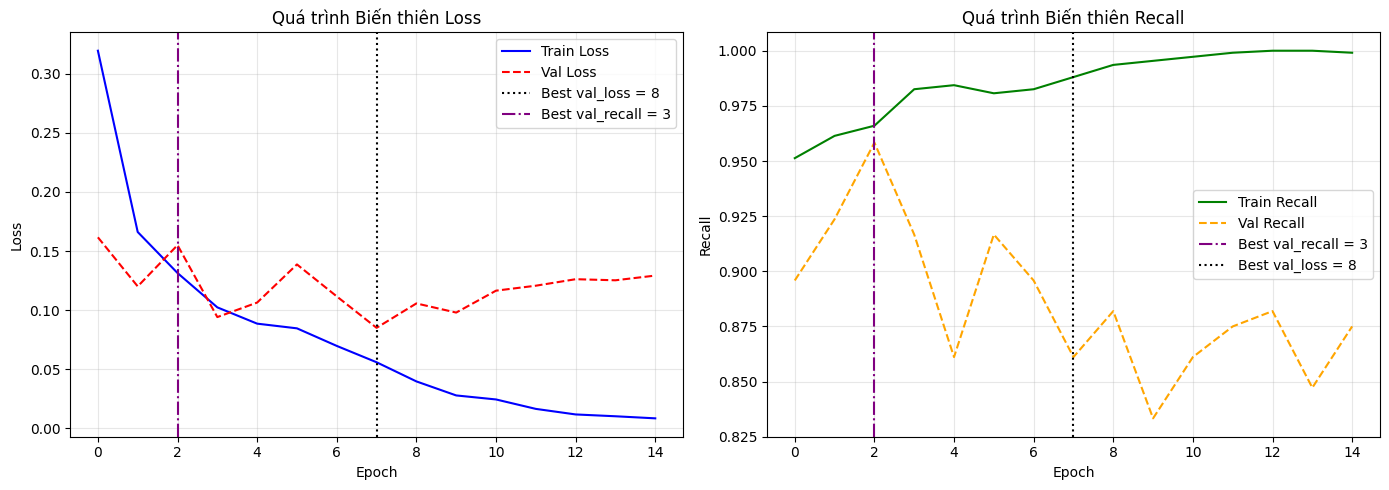

In [7]:
from tensorflow.keras.callbacks import ModelCheckpoint

os.makedirs("saved_models", exist_ok=True)
best_model_path = os.path.join("saved_models", "best_model.keras")

callbacks = [
    ModelCheckpoint(
        filepath=best_model_path,
        monitor="val_recall",
        mode="max",
        save_best_only=True,
        save_weights_only=False,
        verbose=1,
    ),
    EarlyStopping(
        monitor="val_recall",
        mode="max",
        patience=12,
        min_delta=1e-3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-5,
        verbose=1
    )
]

history = model.fit(
    X_train_aug,
    y_train_aug,
    validation_data=(X_val, y_val),
    batch_size=32,
    epochs=100,
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1
)

loss_history = np.asarray(history.history["loss"])
val_loss_history = np.asarray(history.history["val_loss"])
val_recall_history = np.asarray(history.history["val_recall"])

best_recall_epoch = int(np.argmax(val_recall_history) + 1)
best_loss_epoch = int(np.argmin(val_loss_history) + 1)
stop_epoch = len(val_loss_history)

print(f"Best val_recall: epoch {best_recall_epoch} ({val_recall_history[best_recall_epoch - 1]:.6f})")
print(f"Best val_loss: epoch {best_loss_epoch} ({val_loss_history[best_loss_epoch - 1]:.6f})")
print(f"Val recall at best val_loss epoch: {val_recall_history[best_loss_epoch - 1]:.6f}")
print(f"Val recall at best val_recall epoch: {val_recall_history[best_recall_epoch - 1]:.6f}")
print(f"Stopped after: epoch {stop_epoch}")
print(f"Train loss at best val_recall epoch: {loss_history[best_recall_epoch - 1]:.6f}")
print(f"Best model saved during training at: {best_model_path}")
print("Lưu ý: train loss có class_weight, còn val_loss và val_recall mặc định không có class_weight.")

# Confusion matrix trên Validation tại threshold 0.5.
val_probs_at_05 = model.predict(X_val, verbose=0).ravel()
val_preds_at_05 = (val_probs_at_05 >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_val, val_preds_at_05, labels=[0, 1]).ravel()

print("\nConfusion Matrix trên Validation (threshold = 0.5)")
print(f"TP (Fall -> Fall):     {tp}")
print(f"FN (Fall -> Normal):   {fn}")
print(f"FP (Normal -> Fall):   {fp}")
print(f"TN (Normal -> Normal): {tn}")
print(f"Recall tại threshold 0.5: {recall_score(y_val, val_preds_at_05, zero_division=0):.6f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["loss"], label="Train Loss", color="blue")
axes[0].plot(history.history["val_loss"], label="Val Loss", color="red", linestyle="--")
axes[0].axvline(best_loss_epoch - 1, color="black", linestyle=":", label=f"Best val_loss = {best_loss_epoch}")
axes[0].axvline(best_recall_epoch - 1, color="purple", linestyle="-.", label=f"Best val_recall = {best_recall_epoch}")
axes[0].set_title("Quá trình Biến thiên Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history["recall"], label="Train Recall", color="green")
axes[1].plot(history.history["val_recall"], label="Val Recall", color="orange", linestyle="--")
axes[1].axvline(best_recall_epoch - 1, color="purple", linestyle="-.", label=f"Best val_recall = {best_recall_epoch}")
axes[1].axvline(best_loss_epoch - 1, color="black", linestyle=":", label=f"Best val_loss = {best_loss_epoch}")
axes[1].set_title("Quá trình Biến thiên Recall")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Recall")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 6. Tối ưu hóa ngưỡng quyết định (Threshold Tuning trên tập Validation)
Do dữ liệu mất cân bằng và có sử dụng `class_weight`, ngưỡng mặc định 0.5 chưa chắc đã tối ưu. Chúng ta quét ngưỡng $\theta \in [0.1, 0.9]$ trên tập Validation để chọn ra ngưỡng đạt **F1-Score cao nhất cho lớp Ngã**.

==> Ngưỡng được chọn trên Validation: 0.55
    - Quy tắc chọn: Recall >= 0.95, sau đó tối đa hóa F2
    - F2-Score (ưu tiên Recall): 0.8835
    - Recall:                  0.9583
    - Precision:               0.6732


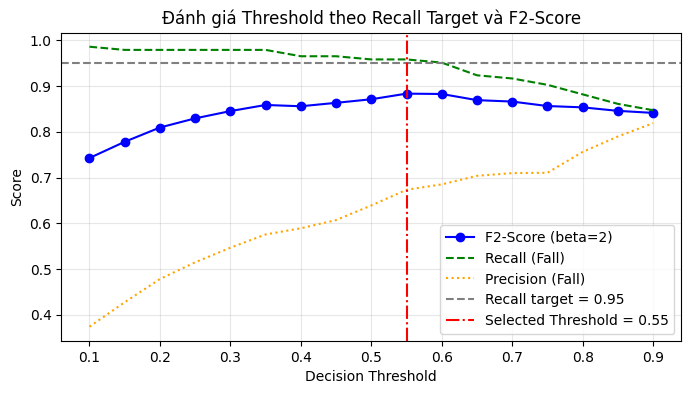

In [8]:
val_probs = model.predict(X_val, verbose=0).ravel()

RECALL_TARGET = 0.95
thresholds = np.arange(0.1, 0.95, 0.05)
f2_scores = []
recalls = []
precisions = []

for th in thresholds:
    preds = (val_probs >= th).astype(int)
    f2_scores.append(fbeta_score(y_val, preds, beta=2, zero_division=0))
    recalls.append(recall_score(y_val, preds, zero_division=0))
    precisions.append(precision_score(y_val, preds, zero_division=0))

f2_scores = np.asarray(f2_scores)
recalls = np.asarray(recalls)
precisions = np.asarray(precisions)

eligible_indices = np.flatnonzero(recalls >= RECALL_TARGET)
if len(eligible_indices) > 0:
    best_idx = eligible_indices[np.argmax(f2_scores[eligible_indices])]
    selection_rule = f"Recall >= {RECALL_TARGET:.2f}, sau đó tối đa hóa F2"
else:
    best_idx = np.lexsort((-f2_scores, -recalls))[0]
    selection_rule = "Không có threshold đạt mục tiêu; ưu tiên Recall cao nhất, sau đó F2"

best_threshold = thresholds[best_idx]
best_f2 = f2_scores[best_idx]

print(f"==> Ngưỡng được chọn trên Validation: {best_threshold:.2f}")
print(f"    - Quy tắc chọn: {selection_rule}")
print(f"    - F2-Score (ưu tiên Recall): {best_f2:.4f}")
print(f"    - Recall:                  {recalls[best_idx]:.4f}")
print(f"    - Precision:               {precisions[best_idx]:.4f}")

# Vẽ đồ thị Threshold vs Metrics
plt.figure(figsize=(8, 4))
plt.plot(thresholds, f2_scores, label="F2-Score (beta=2)", marker="o", color="blue")
plt.plot(thresholds, recalls, label="Recall (Fall)", linestyle="--", color="green")
plt.plot(thresholds, precisions, label="Precision (Fall)", linestyle=":", color="orange")
plt.axhline(RECALL_TARGET, color="gray", linestyle="--", label=f"Recall target = {RECALL_TARGET:.2f}")
plt.axvline(best_threshold, color="red", linestyle="-.", label=f"Selected Threshold = {best_threshold:.2f}")
plt.title("Đánh giá Threshold theo Recall Target và F2-Score")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 8. Đánh giá trên toàn bộ tệp Sample Test

Test root: /Users/bach/Downloads/AI Projects/Fall_Detection_SIC_Capstone/fall_detection_dataset/Sample_Test
Các subject test: ['SA21', 'SA23', 'SA24', 'SA26', 'SA30', 'SA33']

 ĐANG ĐÁNH GIÁ SUBJECT: SA21
Đang đọc 98 file CSV từ: /Users/bach/Downloads/AI Projects/Fall_Detection_SIC_Capstone/fall_detection_dataset/Sample_Test/SA21
Kích thước raw data: (50039, 17)
Số window: 358
Normal: 332 | Fall: 26


/Users/bach/Downloads/AI Projects/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(



Accuracy       : 0.9637
Precision Fall : 0.6857
Recall Fall    : 0.9231
F1 Fall        : 0.7869
F1 Macro       : 0.8835
ROC-AUC        : 0.9943
TN=321 | FP=11 | FN=2 | TP=24

 ĐANG ĐÁNH GIÁ SUBJECT: SA23
Đang đọc 100 file CSV từ: /Users/bach/Downloads/AI Projects/Fall_Detection_SIC_Capstone/fall_detection_dataset/Sample_Test/SA23
Kích thước raw data: (45041, 17)
Số window: 299
Normal: 275 | Fall: 24

Accuracy       : 0.9164
Precision Fall : 0.4884
Recall Fall    : 0.8750
F1 Fall        : 0.6269
F1 Macro       : 0.7899
ROC-AUC        : 0.9776
TN=253 | FP=22 | FN=3 | TP=21

 ĐANG ĐÁNH GIÁ SUBJECT: SA24
Đang đọc 93 file CSV từ: /Users/bach/Downloads/AI Projects/Fall_Detection_SIC_Capstone/fall_detection_dataset/Sample_Test/SA24


/Users/bach/Downloads/AI Projects/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Kích thước raw data: (48078, 17)
Số window: 344
Normal: 318 | Fall: 26

Accuracy       : 0.9506
Precision Fall : 0.6098
Recall Fall    : 0.9615
F1 Fall        : 0.7463
F1 Macro       : 0.8594
ROC-AUC        : 0.9915
TN=302 | FP=16 | FN=1 | TP=25

 ĐANG ĐÁNH GIÁ SUBJECT: SA26
Đang đọc 97 file CSV từ: /Users/bach/Downloads/AI Projects/Fall_Detection_SIC_Capstone/fall_detection_dataset/Sample_Test/SA26


...


Accuracy       : 0.9594
Precision Fall : 0.6471
Recall Fall    : 0.9565
F1 Fall        : 0.7719
F1 Macro       : 0.8748
ROC-AUC        : 0.9902
TN=285 | FP=12 | FN=1 | TP=22

 ĐANG ĐÁNH GIÁ SUBJECT: SA33
Đang đọc 99 file CSV từ: /Users/bach/Downloads/AI Projects/Fall_Detection_SIC_Capstone/fall_detection_dataset/Sample_Test/SA33
Kích thước raw data: (47455, 17)
Số window: 323
Normal: 301 | Fall: 22


/Users/bach/Downloads/AI Projects/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(



Accuracy       : 0.9752
Precision Fall : 0.7692
Recall Fall    : 0.9091
F1 Fall        : 0.8333
F1 Macro       : 0.9100
ROC-AUC        : 0.9953
TN=295 | FP=6 | FN=2 | TP=20


 KẾT QUẢ TỪNG SUBJECT


,Subject,Windows,Normal,Fall,Accuracy,Precision_Fall,Recall_Fall,F1_Fall,F1_Macro,ROC_AUC,TN,FP,FN,TP
0,SA21,358,332,26,0.9637,0.6857,0.9231,0.7869,0.8835,0.9943,321,11,2,24
1,SA23,299,275,24,0.9164,0.4884,0.8750,0.6269,0.7899,0.9776,253,22,3,21
2,SA24,344,318,26,0.9506,0.6098,0.9615,0.7463,0.8594,0.9915,302,16,1,25
3,SA26,355,322,33,0.9606,0.7111,0.9697,0.8205,0.8992,0.9832,309,13,1,32
4,SA30,320,297,23,0.9594,0.6471,0.9565,0.7719,0.8748,0.9902,285,12,1,22
5,SA33,323,301,22,0.9752,0.7692,0.9091,0.8333,0.9100,0.9953,295,6,2,20



 KẾT QUẢ TỔNG TOÀN BỘ SAMPLE_TEST
Số subjects     : 6
Tổng windows    : 1999
Normal windows  : 1845
Fall windows    : 154

Accuracy        : 0.9550
Precision Fall  : 0.6429
Recall Fall     : 0.9351
F1 Fall         : 0.7619
F2 Fall         : 0.8571
F1 Macro        : 0.8685
ROC-AUC         : 0.9889

TN: 1765
FP: 80
FN: 10
TP: 144

Classification Report - ALL TEST SUBJECTS:
                 precision    recall  f1-score   support

Bình thường (0)     0.9944    0.9566    0.9751      1845
        Ngã (1)     0.6429    0.9351    0.7619       154

       accuracy                         0.9550      1999
      macro avg     0.8186    0.9459    0.8685      1999
   weighted avg     0.9673    0.9550    0.9587      1999



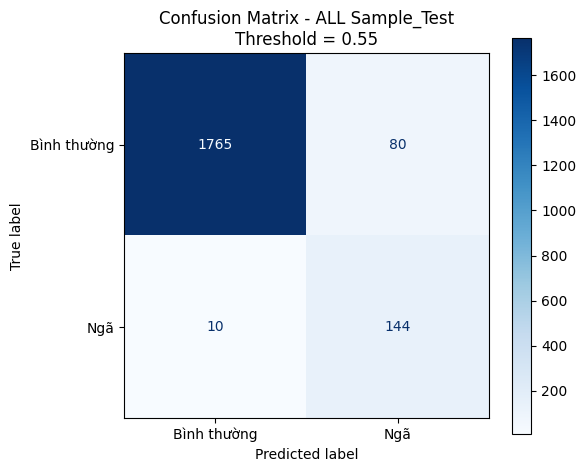


 TRUNG BÌNH THEO SUBJECT
Mean Accuracy       : 0.9543
Mean Precision Fall : 0.6519
Mean Recall Fall    : 0.9325
Mean F1 Fall        : 0.7643
Mean ROC-AUC        : 0.9887


In [14]:
# ============================================================
# ĐÁNH GIÁ TOÀN BỘ SAMPLE_TEST
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# ============================================================
# 1. ĐƯỜNG DẪN THƯ MỤC SAMPLE_TEST
# ============================================================

test_root = resolve_dataset_path(
    "Fall_Detection_SIC_Capstone/fall_detection_dataset/Sample_Test",
    "fall_detection_dataset/Sample_Test",
)

print("Test root:", test_root)


# ============================================================
# 2. TÌM TẤT CẢ SUBJECT TEST: SA21, SA23, ...
# ============================================================

test_subject_dirs = sorted(
    [
        p for p in Path(test_root).iterdir()
        if p.is_dir() and p.name.startswith("SA")
    ],
    key=lambda p: p.name
)

if len(test_subject_dirs) == 0:
    raise ValueError(
        f"Không tìm thấy folder SAxx nào trong {test_root}"
    )

print(
    "Các subject test:",
    [p.name for p in test_subject_dirs]
)


# ============================================================
# 3. BIẾN LƯU KẾT QUẢ TOÀN BỘ TEST
# ============================================================

all_y_true = []
all_y_pred = []
all_y_prob = []

all_recordings = []
all_subjects = []

subject_results = []


# ============================================================
# 4. TEST TỪNG SUBJECT
# ============================================================

for subject_dir in test_subject_dirs:

    subject_name = subject_dir.name

    print("\n" + "=" * 65)
    print(f" ĐANG ĐÁNH GIÁ SUBJECT: {subject_name}")
    print("=" * 65)

    # --------------------------------------------------------
    # Load raw IMU data của subject
    # --------------------------------------------------------

    df_test = load_imu_dataset(
        subject_dir
    )

    print(
        f"Kích thước raw data: {df_test.shape}"
    )


    # --------------------------------------------------------
    # Scale bằng scaler đã fit trên TRAIN
    #
    # TUYỆT ĐỐI không fit scaler lại trên test.
    # --------------------------------------------------------

    df_test_scaled = df_test.copy()

    df_test_scaled[feature_cols] = scaler.transform(
        df_test_scaled[feature_cols]
    )


    # --------------------------------------------------------
    # Sliding window RIÊNG cho subject hiện tại
    #
    # Vì create_sliding_windows() còn group theo recording_id,
    # window cũng không vượt qua recording boundary.
    # --------------------------------------------------------

    X_test, y_test, test_recordings, test_window_subjects = (
        create_sliding_windows(
            df_test_scaled,
            feature_cols,
            target_col,
            WINDOW_SIZE,
            WINDOW_STEP,
        )
    )


    print(
        f"Số window: {len(X_test)}"
    )

    print(
        f"Normal: {np.sum(y_test == 0)} | "
        f"Fall: {np.sum(y_test == 1)}"
    )


    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    test_probs = model.predict(
        X_test,
        verbose=0
    ).ravel()

    y_pred = (
        test_probs >= best_threshold
    ).astype(int)


    # ========================================================
    # METRICS SUBJECT
    # ========================================================

    acc = accuracy_score(
        y_test,
        y_pred
    )

    precision_fall = precision_score(
        y_test,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    recall_fall = recall_score(
        y_test,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    f1_fall = f1_score(
        y_test,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    f1_macro = f1_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )


    # ROC-AUC chỉ tính được nếu subject có cả 2 lớp
    if len(np.unique(y_test)) == 2:

        auc = roc_auc_score(
            y_test,
            test_probs
        )

    else:

        auc = np.nan


    # --------------------------------------------------------
    # Confusion matrix
    # --------------------------------------------------------

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    ).ravel()


    print(
        f"\nAccuracy       : {acc:.4f}"
    )

    print(
        f"Precision Fall : {precision_fall:.4f}"
    )

    print(
        f"Recall Fall    : {recall_fall:.4f}"
    )

    print(
        f"F1 Fall        : {f1_fall:.4f}"
    )

    print(
        f"F1 Macro       : {f1_macro:.4f}"
    )

    if not np.isnan(auc):
        print(
            f"ROC-AUC        : {auc:.4f}"
        )

    print(
        f"TN={tn} | FP={fp} | FN={fn} | TP={tp}"
    )


    # --------------------------------------------------------
    # Lưu metric subject
    # --------------------------------------------------------

    subject_results.append({

        "Subject": subject_name,

        "Windows": len(y_test),

        "Normal": int(
            np.sum(y_test == 0)
        ),

        "Fall": int(
            np.sum(y_test == 1)
        ),

        "Accuracy": acc,

        "Precision_Fall": precision_fall,

        "Recall_Fall": recall_fall,

        "F1_Fall": f1_fall,

        "F1_Macro": f1_macro,

        "ROC_AUC": auc,

        "TN": int(tn),

        "FP": int(fp),

        "FN": int(fn),

        "TP": int(tp),
    })


    # --------------------------------------------------------
    # Gộp prediction SAU KHI đã window riêng
    # --------------------------------------------------------

    all_y_true.append(
        y_test
    )

    all_y_pred.append(
        y_pred
    )

    all_y_prob.append(
        test_probs
    )

    all_recordings.append(
        test_recordings
    )

    all_subjects.append(
        np.full(
            len(y_test),
            subject_name
        )
    )


# ============================================================
# 5. GỘP TOÀN BỘ TEST WINDOWS
# ============================================================

all_y_true = np.concatenate(
    all_y_true
)

all_y_pred = np.concatenate(
    all_y_pred
)

all_y_prob = np.concatenate(
    all_y_prob
)

all_recordings = np.concatenate(
    all_recordings
)

all_subjects = np.concatenate(
    all_subjects
)


# ============================================================
# 6. BẢNG KẾT QUẢ TỪNG SUBJECT
# ============================================================

results_df = pd.DataFrame(
    subject_results
)

print("\n\n" + "=" * 90)
print(" KẾT QUẢ TỪNG SUBJECT")
print("=" * 90)

display(
    results_df.round(4)
)


# ============================================================
# 7. METRICS TỔNG TOÀN BỘ SAMPLE_TEST
# ============================================================

overall_acc = accuracy_score(
    all_y_true,
    all_y_pred
)

overall_precision = precision_score(
    all_y_true,
    all_y_pred,
    pos_label=1,
    zero_division=0
)

overall_recall = recall_score(
    all_y_true,
    all_y_pred,
    pos_label=1,
    zero_division=0
)

overall_f1 = f1_score(
    all_y_true,
    all_y_pred,
    pos_label=1,
    zero_division=0
)

overall_f1_macro = f1_score(
    all_y_true,
    all_y_pred,
    average="macro",
    zero_division=0
)

overall_auc = roc_auc_score(
    all_y_true,
    all_y_prob
)

tn, fp, fn, tp = confusion_matrix(
    all_y_true,
    all_y_pred,
    labels=[0, 1]
).ravel()


# F2 vì bài toán ưu tiên Recall
beta = 2

overall_f2 = (
    (1 + beta**2)
    * overall_precision
    * overall_recall
    /
    (
        beta**2 * overall_precision
        + overall_recall
        + 1e-8
    )
)


# ============================================================
# 8. IN KẾT QUẢ TỔNG
# ============================================================

print("\n" + "=" * 65)
print(" KẾT QUẢ TỔNG TOÀN BỘ SAMPLE_TEST")
print("=" * 65)

print(
    f"Số subjects     : {len(test_subject_dirs)}"
)

print(
    f"Tổng windows    : {len(all_y_true)}"
)

print(
    f"Normal windows  : {np.sum(all_y_true == 0)}"
)

print(
    f"Fall windows    : {np.sum(all_y_true == 1)}"
)

print()

print(
    f"Accuracy        : {overall_acc:.4f}"
)

print(
    f"Precision Fall  : {overall_precision:.4f}"
)

print(
    f"Recall Fall     : {overall_recall:.4f}"
)

print(
    f"F1 Fall         : {overall_f1:.4f}"
)

print(
    f"F2 Fall         : {overall_f2:.4f}"
)

print(
    f"F1 Macro        : {overall_f1_macro:.4f}"
)

print(
    f"ROC-AUC         : {overall_auc:.4f}"
)

print()

print(
    f"TN: {tn}"
)

print(
    f"FP: {fp}"
)

print(
    f"FN: {fn}"
)

print(
    f"TP: {tp}"
)


# ============================================================
# 9. CLASSIFICATION REPORT TỔNG
# ============================================================

print(
    "\nClassification Report - ALL TEST SUBJECTS:"
)

print(
    classification_report(
        all_y_true,
        all_y_pred,
        labels=[0, 1],
        target_names=[
            "Bình thường (0)",
            "Ngã (1)"
        ],
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 10. CONFUSION MATRIX TỔNG
# ============================================================

fig, ax = plt.subplots(
    figsize=(6, 5)
)

cm = confusion_matrix(
    all_y_true,
    all_y_pred,
    labels=[0, 1]
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Bình thường",
        "Ngã"
    ]
).plot(
    cmap="Blues",
    values_format="d",
    ax=ax
)

ax.set_title(
    "Confusion Matrix - ALL Sample_Test\n"
    f"Threshold = {best_threshold:.2f}"
)

plt.tight_layout()
plt.show()


# ============================================================
# 11. MACRO AVERAGE THEO SUBJECT
# ============================================================

print("\n" + "=" * 65)
print(" TRUNG BÌNH THEO SUBJECT")
print("=" * 65)

print(
    f"Mean Accuracy       : "
    f"{results_df['Accuracy'].mean():.4f}"
)

print(
    f"Mean Precision Fall : "
    f"{results_df['Precision_Fall'].mean():.4f}"
)

print(
    f"Mean Recall Fall    : "
    f"{results_df['Recall_Fall'].mean():.4f}"
)

print(
    f"Mean F1 Fall        : "
    f"{results_df['F1_Fall'].mean():.4f}"
)

print(
    f"Mean ROC-AUC        : "
    f"{results_df['ROC_AUC'].mean():.4f}"
)

In [15]:
# ============================================================
# FINE-TUNING MODEL
# ============================================================

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

# ------------------------------------------------------------
# 1. Load lại checkpoint tốt nhất
# ------------------------------------------------------------

print("Load best model:", best_model_path)

model_ft = tf.keras.models.load_model(
    best_model_path
)

# ------------------------------------------------------------
# 2. Compile lại với learning rate nhỏ hơn
# ------------------------------------------------------------
# Training ban đầu: lr = 1e-3
# Fine-tuning:      lr = 1e-4

model_ft.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss="binary_crossentropy",

    metrics=[
        "accuracy",

        tf.keras.metrics.Precision(
            name="precision"
        ),

        tf.keras.metrics.Recall(
            name="recall"
        ),

        tf.keras.metrics.AUC(
            name="auc"
        )
    ]
)

# ------------------------------------------------------------
# 3. Callback cho fine-tuning
# ------------------------------------------------------------

os.makedirs("saved_models", exist_ok=True)

fine_tuned_model_path = os.path.join(
    "saved_models",
    "fall_detection_finetuned.keras"
)

callbacks_ft = [

    # Vẫn ưu tiên khả năng bắt Fall
    ModelCheckpoint(
        filepath=fine_tuned_model_path,
        monitor="val_recall",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    # Fine-tuning không cần train quá lâu
    EarlyStopping(
        monitor="val_recall",
        mode="max",
        patience=6,
        min_delta=1e-3,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

# ------------------------------------------------------------
# 4. Fine-tune
# ------------------------------------------------------------

history_ft = model_ft.fit(
    X_train_aug,
    y_train_aug,

    validation_data=(
        X_val,
        y_val
    ),

    batch_size=32,

    # Chỉ fine-tune thêm một số epoch nhỏ
    epochs=20,

    callbacks=callbacks_ft,

    class_weight=class_weight,

    verbose=1
)

# ------------------------------------------------------------
# 5. Load lại checkpoint tốt nhất của fine-tuning
# ------------------------------------------------------------

model_ft = tf.keras.models.load_model(
    fine_tuned_model_path
)

print("\nFine-tuning hoàn tất.")
print("Best fine-tuned model:", fine_tuned_model_path)

# ------------------------------------------------------------
# 6. Evaluate nhanh ở threshold mặc định 0.5
# ------------------------------------------------------------

results = model_ft.evaluate(
    X_val,
    y_val,
    verbose=0
)

print("\nValidation metrics:")
for name, value in zip(
    model_ft.metrics_names,
    results
):
    print(f"{name}: {value:.4f}")

Load best model: saved_models/best_model.keras
Epoch 1/20
430/431 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9670 - auc: 0.9935 - loss: 0.0963 - precision: 0.7146 - recall: 0.9784
Epoch 1: val_recall improved from None to 0.90972, saving model to saved_models/fall_detection_finetuned.keras

Epoch 1: finished saving model to saved_models/fall_detection_finetuned.keras
431/431 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.9658 - auc: 0.9943 - loss: 0.0901 - precision: 0.7044 - recall: 0.9770 - val_accuracy: 0.9673 - val_auc: 0.9887 - val_loss: 0.1056 - val_precision: 0.7443 - val_recall: 0.9097 - learning_rate: 1.0000e-04
Epoch 2/20
430/431 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9723 - auc: 0.9954 - loss: 0.0783 - precision: 0.7468 - recall: 0.9877
Epoch 2: val_recall did not improve from 0.90972
431/431 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.9715 - auc: 0.9955 - loss: 0.0780 - precision: 0.7388 - recall: 0.9881 - val_accuracy: 0.9662 - val_auc: 0.9892 - val_lo

In [16]:
# ============================================================
# CONVERT FINE-TUNED KERAS MODEL -> TFLITE
# ============================================================

import os
import tensorflow as tf

KERAS_PATH = "saved_models/fall_detection_finetuned.keras"
TFLITE_PATH = "saved_models/fall_detection_finetuned.tflite"

# 1. Load model fine-tuned
model_export = tf.keras.models.load_model(
    KERAS_PATH
)

print("Loaded:", KERAS_PATH)

# 2. Convert sang TFLite Float32
converter = tf.lite.TFLiteConverter.from_keras_model(
    model_export
)

tflite_model = converter.convert()

# 3. Save vào saved_models
with open(TFLITE_PATH, "wb") as f:
    f.write(tflite_model)

print("\nTFLite export thành công!")
print("Path:", os.path.abspath(TFLITE_PATH))
print(
    "Size:",
    round(os.path.getsize(TFLITE_PATH) / 1024, 2),
    "KB"
)

# 4. Kiểm tra danh sách file
print("\nFiles trong saved_models:")
for file in os.listdir("saved_models"):
    print(" -", file)

Loaded: saved_models/fall_detection_finetuned.keras
INFO:tensorflow:Assets written to: /var/folders/cf/6f5g7m5d5dgg3blzc0clqglh0000gn/T/tmpt8o1d4lm/assets


INFO:tensorflow:Assets written to: /var/folders/cf/6f5g7m5d5dgg3blzc0clqglh0000gn/T/tmpt8o1d4lm/assets


Saved artifact at '/var/folders/cf/6f5g7m5d5dgg3blzc0clqglh0000gn/T/tmpt8o1d4lm'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1600), dtype=tf.float32, name='input_sensor_features')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  5149123280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13560071568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13560075600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5150565840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5149122896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13560075792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13560070224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13560070800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13560071376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13560079248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13560075984

W0000 00:00:1788667596.984877 3015720 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1788667596.985005 3015720 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1788667596.987653 3015720 reader.cc:83] Reading SavedModel from: /var/folders/cf/6f5g7m5d5dgg3blzc0clqglh0000gn/T/tmpt8o1d4lm
I0000 00:00:1788667596.990261 3015720 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1788667596.990272 3015720 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/cf/6f5g7m5d5dgg3blzc0clqglh0000gn/T/tmpt8o1d4lm
I0000 00:00:1788667597.017213 3015720 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1788667597.023307 3015720 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1788667597.170488 3015720 loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/cf/6f5g7m5d5dgg3blzc0clqglh0000gn/T/tmpt8o1d4lm
I0000 00:00:1788667597.216235 3015720 lo

In [17]:
# ============================================================
# EXPORT TFLITE + SCALER -> C/C++ FILES
#
# Output:
#   saved_models/model_data.cc
#   saved_models/model_data.h
#   saved_models/scaler_data.h
# ============================================================

import os
import pickle
import joblib
import numpy as np


# ============================================================
# 1. PATH CONFIG
# ============================================================

MODEL_DIR = "saved_models"

TFLITE_PATH = os.path.join(
    MODEL_DIR,
    "fall_detection_finetuned.tflite"
)

SCALER_PATH = os.path.join(
    MODEL_DIR,
    "scaler.pkl"
)

METADATA_PATH = os.path.join(
    MODEL_DIR,
    "metadata.pkl"
)

MODEL_CC_PATH = os.path.join(
    MODEL_DIR,
    "model_data.cc"
)

MODEL_H_PATH = os.path.join(
    MODEL_DIR,
    "model_data.h"
)

SCALER_H_PATH = os.path.join(
    MODEL_DIR,
    "scaler_data.h"
)


# ============================================================
# 2. CHECK INPUT FILES
# ============================================================

required_files = [
    TFLITE_PATH,
    SCALER_PATH
]

for path in required_files:
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Không tìm thấy file: {path}"
        )

print("Found TFLite :", TFLITE_PATH)
print("Found Scaler :", SCALER_PATH)


# ============================================================
# 3. LOAD SCALER
# ============================================================

scaler_export = joblib.load(
    SCALER_PATH
)

scaler_mean = np.asarray(
    scaler_export.mean_,
    dtype=np.float32
).reshape(-1)

scaler_scale = np.asarray(
    scaler_export.scale_,
    dtype=np.float32
).reshape(-1)

if len(scaler_mean) != len(scaler_scale):
    raise ValueError(
        "scaler.mean_ và scaler.scale_ không cùng kích thước."
    )

SCALER_SIZE = len(scaler_mean)

print(
    "Scaler size:",
    SCALER_SIZE
)


# ============================================================
# 4. LOAD METADATA NẾU CÓ
# ============================================================

metadata_export = {}

if os.path.exists(METADATA_PATH):

    try:
        metadata_export = joblib.load(
            METADATA_PATH
        )

    except Exception:

        with open(
            METADATA_PATH,
            "rb"
        ) as f:
            metadata_export = pickle.load(f)

    if not isinstance(metadata_export, dict):
        print(
            "WARNING: metadata.pkl không phải dict, "
            "sẽ ưu tiên các biến hiện tại trong notebook."
        )
        metadata_export = {}

else:

    print(
        "WARNING: Không tìm thấy metadata.pkl. "
        "Sẽ sử dụng biến hiện tại trong notebook."
    )


# ============================================================
# 5. GET CONFIG TỪ NOTEBOOK / METADATA
# ============================================================

# ------------------------------------------------------------
# Threshold
# Ưu tiên best_threshold hiện tại vì đây có thể là threshold
# vừa được tune lại sau fine-tuning.
# ------------------------------------------------------------

if "best_threshold" in globals():

    EXPORT_THRESHOLD = float(
        best_threshold
    )

elif "decision_threshold" in metadata_export:

    EXPORT_THRESHOLD = float(
        metadata_export["decision_threshold"]
    )

elif "best_threshold" in metadata_export:

    EXPORT_THRESHOLD = float(
        metadata_export["best_threshold"]
    )

else:

    raise ValueError(
        "Không tìm thấy best_threshold. "
        "Hãy chạy cell threshold tuning trước."
    )


# ------------------------------------------------------------
# Window size
# ------------------------------------------------------------

if "WINDOW_SIZE" in globals():

    EXPORT_WINDOW_SIZE = int(
        WINDOW_SIZE
    )

elif "window_size" in metadata_export:

    EXPORT_WINDOW_SIZE = int(
        metadata_export["window_size"]
    )

else:

    raise ValueError(
        "Không tìm thấy WINDOW_SIZE."
    )


# ------------------------------------------------------------
# Window step
# ------------------------------------------------------------

if "WINDOW_STEP" in globals():

    EXPORT_WINDOW_STEP = int(
        WINDOW_STEP
    )

elif "window_step" in metadata_export:

    EXPORT_WINDOW_STEP = int(
        metadata_export["window_step"]
    )

else:

    EXPORT_WINDOW_STEP = 0
    print(
        "WARNING: Không tìm thấy WINDOW_STEP."
    )


# ------------------------------------------------------------
# Feature order
# ------------------------------------------------------------

if "feature_cols" in globals():

    EXPORT_FEATURES = list(
        feature_cols
    )

elif "feature_cols" in metadata_export:

    EXPORT_FEATURES = list(
        metadata_export["feature_cols"]
    )

else:

    EXPORT_FEATURES = []

    print(
        "WARNING: Không tìm thấy feature_cols."
    )


NUM_FEATURES = len(
    EXPORT_FEATURES
)

EXPECTED_INPUT_SIZE = (
    EXPORT_WINDOW_SIZE * NUM_FEATURES
    if NUM_FEATURES > 0
    else SCALER_SIZE
)


# ============================================================
# 6. KIỂM TRA SCALER SIZE
# ============================================================

print("\n" + "=" * 60)
print(" MODEL CONFIG")
print("=" * 60)

print(
    "Window size      :",
    EXPORT_WINDOW_SIZE
)

print(
    "Window step      :",
    EXPORT_WINDOW_STEP
)

print(
    "Features         :",
    EXPORT_FEATURES
)

print(
    "Num features     :",
    NUM_FEATURES
)

print(
    "Expected input   :",
    EXPECTED_INPUT_SIZE
)

print(
    "Scaler size      :",
    SCALER_SIZE
)

print(
    "Fall threshold   :",
    EXPORT_THRESHOLD
)


if (
    NUM_FEATURES > 0
    and SCALER_SIZE != EXPECTED_INPUT_SIZE
):

    print(
        "\nWARNING:"
    )

    print(
        f"Scaler có {SCALER_SIZE} giá trị "
        f"nhưng WINDOW_SIZE × NUM_FEATURES = "
        f"{EXPECTED_INPUT_SIZE}."
    )

    print(
        "Hãy kiểm tra lại preprocessing trước khi nhúng."
    )


# ============================================================
# 7. READ TFLITE BINARY
# ============================================================

with open(
    TFLITE_PATH,
    "rb"
) as f:

    model_bytes = f.read()

MODEL_SIZE = len(
    model_bytes
)

print(
    "\nTFLite model size:",
    MODEL_SIZE,
    "bytes"
)

print(
    "TFLite model size:",
    round(
        MODEL_SIZE / 1024,
        2
    ),
    "KB"
)


# ============================================================
# 8. GENERATE model_data.h
# ============================================================

model_h = """\
#ifndef MODEL_DATA_H_
#define MODEL_DATA_H_

#include <cstddef>
#include <cstdint>

// TensorFlow Lite model embedded as a byte array.
extern const unsigned char g_fall_model[];
extern const unsigned int g_fall_model_len;

#endif  // MODEL_DATA_H_
"""


with open(
    MODEL_H_PATH,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        model_h
    )


# ============================================================
# 9. GENERATE model_data.cc
# ============================================================

BYTES_PER_LINE = 12

lines = []

for i in range(
    0,
    MODEL_SIZE,
    BYTES_PER_LINE
):

    chunk = model_bytes[
        i:i + BYTES_PER_LINE
    ]

    byte_string = ", ".join(
        f"0x{b:02x}"
        for b in chunk
    )

    lines.append(
        "    " + byte_string
    )


model_array_text = ",\n".join(
    lines
)


model_cc = f"""\
#include "model_data.h"

// Alignment is useful for TensorFlow Lite Micro.
alignas(16) const unsigned char g_fall_model[] = {{
{model_array_text}
}};

const unsigned int g_fall_model_len =
    sizeof(g_fall_model);
"""


with open(
    MODEL_CC_PATH,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        model_cc
    )


# ============================================================
# 10. HELPER: FORMAT FLOAT ARRAY
# ============================================================

def format_float_array(
    values,
    values_per_line=6
):

    values = np.asarray(
        values
    ).reshape(-1)

    output_lines = []

    for i in range(
        0,
        len(values),
        values_per_line
    ):

        chunk = values[
            i:i + values_per_line
        ]

        line = ", ".join(
            f"{float(v):.9g}f"
            for v in chunk
        )

        output_lines.append(
            "    " + line
        )

    return ",\n".join(
        output_lines
    )


mean_text = format_float_array(
    scaler_mean
)

scale_text = format_float_array(
    scaler_scale
)


# ============================================================
# 11. FEATURE ORDER COMMENT
# ============================================================

if EXPORT_FEATURES:

    feature_comment = "\n".join(
        f"//   {i}: {name}"
        for i, name in enumerate(
            EXPORT_FEATURES
        )
    )

else:

    feature_comment = (
        "// Feature order unavailable."
    )


# ============================================================
# 12. GENERATE scaler_data.h
# ============================================================

scaler_h = f"""\
#ifndef SCALER_DATA_H_
#define SCALER_DATA_H_

#include <cstddef>

// ============================================================
// FALL DETECTION CONFIGURATION
// ============================================================

constexpr int kWindowSize = {EXPORT_WINDOW_SIZE};
constexpr int kWindowStep = {EXPORT_WINDOW_STEP};
constexpr int kNumFeatures = {NUM_FEATURES};
constexpr int kInputSize = {SCALER_SIZE};

// Probability >= kFallThreshold -> Fall
constexpr float kFallThreshold = {EXPORT_THRESHOLD:.9g}f;


// ============================================================
// FEATURE ORDER
// ============================================================

{feature_comment}


// ============================================================
// STANDARD SCALER
//
// Python preprocessing:
//     x_scaled[i] =
//         (x[i] - scaler.mean_[i])
//         / scaler.scale_[i];
//
// Firmware phải thực hiện chính xác cùng phép biến đổi.
// ============================================================

constexpr float kScalerMean[{SCALER_SIZE}] = {{
{mean_text}
}};


constexpr float kScalerScale[{SCALER_SIZE}] = {{
{scale_text}
}};


// ============================================================
// SCALING HELPER
// ============================================================

inline float StandardizeInput(
    float value,
    int index
) {{
    return (
        value - kScalerMean[index]
    ) / kScalerScale[index];
}}

#endif  // SCALER_DATA_H_
"""


with open(
    SCALER_H_PATH,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        scaler_h
    )


# ============================================================
# 13. RESULT
# ============================================================

print("\n" + "=" * 60)
print(" EXPORT C/C++ SUCCESS")
print("=" * 60)

for path in [
    MODEL_CC_PATH,
    MODEL_H_PATH,
    SCALER_H_PATH
]:

    print(
        f"{path:<35} "
        f"{os.path.getsize(path) / 1024:.2f} KB"
    )


print("\nGenerated files:")

print(
    "1.",
    MODEL_CC_PATH
)

print(
    "2.",
    MODEL_H_PATH
)

print(
    "3.",
    SCALER_H_PATH
)

print("\nThreshold exported:")
print(
    f"kFallThreshold = "
    f"{EXPORT_THRESHOLD:.6f}"
)

print("\nDone.")

Found TFLite : saved_models/fall_detection_finetuned.tflite
Found Scaler : saved_models/scaler.pkl
Scaler size: 8

 MODEL CONFIG
Window size      : 200
Window step      : 100
Features         : ['AccX', 'AccY', 'AccZ', 'AccMag', 'GyrX', 'GyrY', 'GyrZ', 'GyrMag']
Num features     : 8
Expected input   : 1600
Scaler size      : 8
Fall threshold   : 0.5500000000000002

Scaler có 8 giá trị nhưng WINDOW_SIZE × NUM_FEATURES = 1600.
Hãy kiểm tra lại preprocessing trước khi nhúng.

TFLite model size: 224536 bytes
TFLite model size: 219.27 KB

 EXPORT C/C++ SUCCESS
saved_models/model_data.cc          1388.92 KB
saved_models/model_data.h           0.24 KB
saved_models/scaler_data.h          1.63 KB

Generated files:
1. saved_models/model_data.cc
2. saved_models/model_data.h
3. saved_models/scaler_data.h

Threshold exported:
kFallThreshold = 0.550000

Done.
